## Calibration against tidal gauge data

Contains comparision of model output to tidal gauge data by calculating metrics and plotting a time series of water level.

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from pathlib import Path
import sys

# Project root
PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from modules import helpers
from modules import metrics
from modules import read_files as read
from modules import ADCP as custom
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

### Configuration

In [100]:
# period, skip first day
start_date = '2023-01-14'
end_date = '2023-01-18T00'

# model output
dir_model_output = '../../data/calibration/nested_v4_test'
folder_name = 'L1'
layer = 1
name = 'tide gauge Gomera' 

# tidal gauge data
dir_gauge = '../../data/preprocessing/WATER_LEVEL_2023_1_13_2023_2_23.csv'


### Reading files

In [101]:
# model output
all_results = {folder: read.read_files(folder, name, dir_model_output) for folder in [folder_name]}
model_wl = all_results[folder_name][layer]['water_level'].loc[start_date:end_date]

# tidal gauge data
gauge = pd.read_csv(dir_gauge)
gauge['date'] = pd.to_datetime(gauge['date'])
gauge.set_index('date', inplace=True)
gauge = gauge.loc[start_date:end_date]


### Comparision

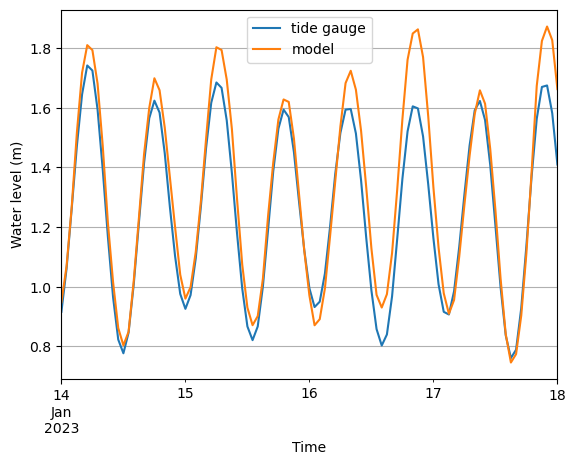

In [102]:
gauge['water_level'].plot(label='tide gauge')
model_wl.plot(label='model')
plt.legend()
plt.ylabel('Water level (m)')
plt.xlabel('Time')
plt.grid(True)
plt.show()

In [96]:
# define metrics to calculate
metric_fns = [metrics.rmse, metrics.bias, metrics.mss, metrics.pearson_r]

df_gauge = metrics.compare_runs(
    runs={
        "model_output": all_results[folder_name][layer]
    },
    reference=gauge,
    metric_fns=metric_fns,
    columns=['water_level'],
)
df_gauge

,run,variable,rmse,bias,mss,pearson_r
0,model_output,water_level,0.114848,0.074633,0.964772,0.96934
